# 📊 Automatic IDF Graphs – Análise Exploratória

Bem-vindo ao notebook de exploração da biblioteca **Automatic-IDF-Graphs** 🚀

## 🧠 O que é esta biblioteca?

A `idf_analysis` é uma biblioteca Python voltada à **geração automática de curvas IDF (Intensidade-Duração-Frequência)** a partir de dados históricos ou projeções climáticas. Ela auxilia na construção de curvas que são fundamentais para:

- Projetos de drenagem urbana e rural 🌧️
- Dimensionamento de obras hidráulicas 🏗️
- Estudos de impacto climático 📉

## ❓ Qual problema ela resolve?

Tradicionalmente, gerar curvas IDF demanda muito tempo e envolvimento manual com dados pluviométricos. A `idf_analysis` automatiza:

- 📥 Coleta e tratamento dos dados
- 📈 Análise estatística e ajuste de distribuições
- 📐 Geração das curvas e tabelas
- 📊 Visualização gráfica

## 🛠️ O que este notebook faz?

Neste notebook, vamos:

- 🔍 Importar e explorar dados de exemplo  
- 📚 Demonstrar as principais funções da biblioteca  
- 📊 Gerar gráficos e curvas IDF com base em dados reais ou sintéticos  
- ✅ Validar resultados com visualizações claras  


> 💡 *Este é um ponto de partida para entender e testar a biblioteca antes de aplicá-la em casos reais.*

#### Seguiremos um passo a passo claro, desde instalações até a visualização dos dados.

---


## ⚙️ Instalação e configuração do ambiente

Instalamos a biblioteca diretamente do repositório GitHub e incluímos a pasta `src/` no `sys.path` para facilitar a importação dos módulos locais.


In [6]:
import sys
import warnings
warnings.filterwarnings('ignore')

print("Instalando a biblioteca...")
%pip install --quiet -e ..
sys.path.append('../src')

print("\nInstalação concluída!")

Instalando a biblioteca...
Note: you may need to restart the kernel to use updated packages.

Instalação concluída!


---
## 📌📆 Requisitando dados brutos de precipitação para a análise.

### 🛠️ Como usar o script interativo para baixar dados (INMET e CEMADEN)

Este projeto inclui um script interativo para facilitar o download de dados meteorológicos do INMET e CEMADEN.

*⚠️ Importante*: As funções de download usam menus interativos via terminal, que **não funcionam dentro de notebooks Jupyter**, especialmente no Windows.

#### ✅ Passos para rodar o script

1. **Abra um terminal** (Prompt de Comando, PowerShell, terminal do VSCode, etc.)

2. Navegue até a raiz do projeto (onde está a pasta `scripts/`):

    ```bash
    cd /caminho/para/Automatic-IDF-Graphs
3. Execute o script:
    ```bash
    python scripts/download_data.py
4. Você verá um menu interativo para escolher entre baixar dados do INMET ou do CEMADEN, e depois escolher parâmetros como estado, estação e período.

### 🖥️ Exemplo de uso
Após rodar o script, o terminal mostrará algo assim:
```bash
    ? Qual base de dados deseja baixar?  (Use as setas ↑ ↓ para navegar)
    ❯ CEMADEN
    INMET

    ✅ Token recebido com sucesso!

    ? Selecione um estado (UF):
    ❯ SP
    RJ
    MG
    ...
    
```

### 📌 Dúvidas e suporte
Se tiver problemas ou sugestões, abra uma issue no GitHub.

---
> ⚠️ *Nesse notebook exploratório foram analisados os dados do Mirante de Santana (São Paulo), dos anos de 2014 a 2024, obtidos com o método acima.*

## 📋 Preenchimento de falhas

Para garantir a qualidade da sua análise, se faz necessário o preenchimento de possíveis falhas nos datasets recebidos. A biblioteca oferece dois métodos de preenchimento:

1. **`Interpolação sazonal`**: utiliza valores de precipitação do mesmo período sazonal (mês/estação) de anos anteriores e posteriores para estimar valores faltantes. Este método considera a variabilidade temporal natural da precipitação, sendo especialmente eficaz para falhas de curta duração em séries longas.

2. **`Utilização de dataset auxiliar`**: emprega dados de estações meteorológicas próximas geograficamente para preencher lacunas, através de correlações espaciais e técnicas de regressão linear ou múltipla.

### 🔧 Quando usar cada método?

- **Interpolação sazonal**: Ideal para falhas pontuais em séries com pelo menos 10 anos de dados
- **Dataset auxiliar**: Recomendado para falhas extensas ou quando há estações próximas com boa correlação

In [1]:
from idf_analysis.data.processing import read_csv, verification, fill_missing_data

# Lendo os DataFrames obtidos
cemaden_df = read_csv(path='../results/cemaden_ac_santana_sao/cemaden_ac_santana_sao_hourly.csv')
inmet_df = read_csv(path='../results/inmet_sao_paulo_-_mirante/inmet_sao_paulo_-_mirante_hourly.csv')

# Verificando falhas
verification(df=cemaden_df,frequency='hourly')
verification(df=inmet_df,frequency='hourly');


[INFO] Período da série: 2014-01-01 00:00:00 até 2025-01-01 23:00:00
[INFO] Períodos esperados: 96456
[INFO] Entradas no DataFrame: 61329

[WARNING] Série incompleta. Períodos faltando: 35127


[INFO] Período da série: 2014-01-01 00:00:00 até 2024-12-31 23:00:00
[INFO] Períodos esperados: 96432
[INFO] Entradas no DataFrame: 96432

[OK] Série completa! Nenhum período faltando.



##### 📑 Nesse caso, a *utlização de um dataset auxiliar* é adequada, pois para a fonte do CEMADEN existem muitos dados faltantes.

In [2]:
cemaden_df = fill_missing_data(path_main='../results/cemaden_ac_santana_sao/cemaden_ac_santana_sao_hourly.csv',
                               path_secondary='../results/inmet_sao_paulo_-_mirante/inmet_sao_paulo_-_mirante_hourly.csv',
                               frequency='hourly',)

# Verificando novamente após o preenchimento
verification(df=cemaden_df, frequency='hourly');


[INFO] Período da série: 2014-01-01 00:00:00 até 2025-01-01 23:00:00
[INFO] Períodos esperados: 96456
[INFO] Entradas no DataFrame: 96456

[OK] Série completa! Nenhum período faltando.



##### ↪️ Caso queira utilizar a interpolação sazonal (não recomendada para uma quantidade alta de dados faltantes):

In [3]:
cemaden_interpolated_df = read_csv(path='../results/cemaden_ac_santana_sao/cemaden_ac_santana_sao_hourly.csv')

# Verificando falhas antes do preenchimento
verification(df=cemaden_interpolated_df, frequency='hourly');

cemaden_interpolated_df = fill_missing_data(path_main='../results/cemaden_ac_santana_sao/cemaden_ac_santana_sao_hourly.csv',
                               frequency='hourly',)

# Verificando novamente após o preenchimento
verification(df=cemaden_interpolated_df, frequency='hourly');


[INFO] Período da série: 2014-01-01 00:00:00 até 2025-01-01 23:00:00
[INFO] Períodos esperados: 96456
[INFO] Entradas no DataFrame: 61329

[WARNING] Série incompleta. Períodos faltando: 35127


[INFO] Período da série: 2014-01-01 00:00:00 até 2025-01-01 23:00:00
[INFO] Períodos esperados: 96456
[INFO] Entradas no DataFrame: 96456

[OK] Série completa! Nenhum período faltando.



---
## 🗃️ Visualização e análise prévia dos dados recebidos

Com os dados carregados, é interessante primeiramente visualizar e analisá-los de forma bruta, para auxiliar na compreensão.

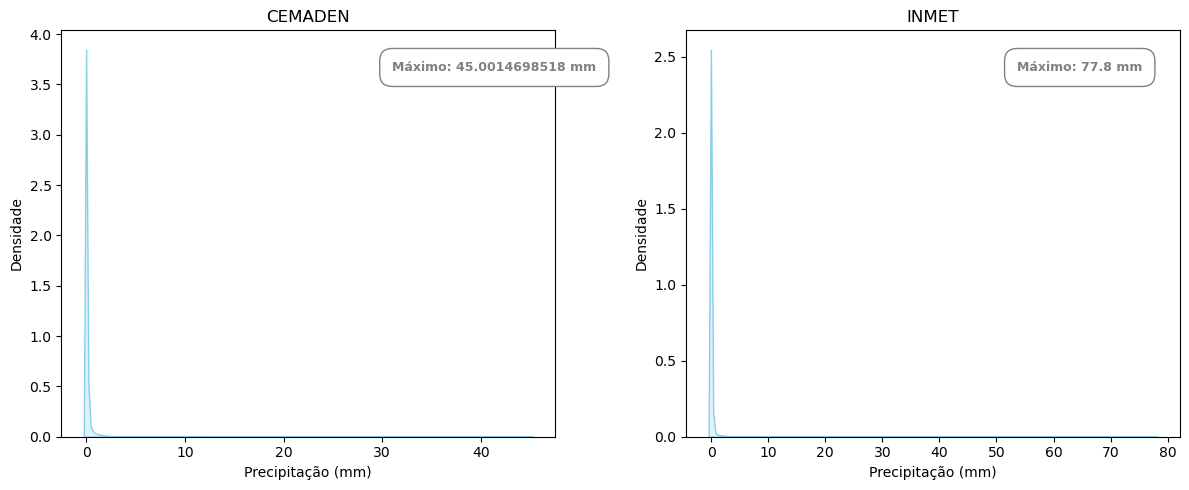

In [4]:

from idf_analysis.visualization.plots import distribution_plot_df
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

distribution_plot_df(df=cemaden_df, show_max=True, ax=axes[0], display=False)
axes[0].set_title("CEMADEN")

distribution_plot_df(df=inmet_df, show_max=True, ax=axes[1], display=False)
axes[1].set_title("INMET")

plt.tight_layout()
plt.show()